In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Huggingface imports for LLaMA
from transformers import LlamaForCausalLM, LlamaTokenizer
import torch


/rodata/kern/m254629/miniconda3/envs/llama2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-05-20 13:24:39.079792: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747765479.092840 1842844 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747765479.096825 1842844 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-20 13:24:39.111498: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in perfo

In [2]:
# Load example data
df = pd.read_csv("diabetes.csv")

# # Example columns: Age, Gender, BloodPressure, Treatment, Outcome
# df = df.dropna()  # Or impute missing data

In [3]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [5]:
# Replace zeros with NaN for certain columns and drop
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    df[col] = df[col].replace(0, np.nan)
df.dropna(inplace=True)

# Variables
treatment = "Glucose"
outcome = "Outcome"
confounders = ['Age', 'BMI', 'Pregnancies']

# Normalize for clearer stats (optional)
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[confounders + [treatment]] = scaler.fit_transform(df[confounders + [treatment]])

# Summarize data for prompt
def summarize_feature(series):
    return f"mean={series.mean():.2f}, std={series.std():.2f}, min={series.min():.2f}, max={series.max():.2f}"

summary_text = f"""
Dataset summary for causal inference:

Treatment variable: {treatment}
  {summarize_feature(df_scaled[treatment])}

Outcome variable: {outcome}
  Outcome distribution: {df_scaled[outcome].value_counts().to_dict()}

Confounders:
"""
for c in confounders:
    summary_text += f"  {c}: {summarize_feature(df_scaled[c])}\n"

summary_text += f"\nTask: Estimate the average treatment effect (ATE) of {treatment} on {outcome}, adjusting for confounders {confounders}."

print("=== Dataset summary sent to LLaMA ===")
print(summary_text)

=== Dataset summary sent to LLaMA ===

Dataset summary for causal inference:

Treatment variable: Glucose
  mean=0.00, std=1.00, min=-2.16, max=2.45

Outcome variable: Outcome
  Outcome distribution: {0: 262, 1: 130}

Confounders:
  Age: mean=0.00, std=1.00, min=-0.97, max=4.92
  BMI: mean=0.00, std=1.00, min=-2.12, max=4.85
  Pregnancies: mean=-0.00, std=1.00, min=-1.03, max=4.27

Task: Estimate the average treatment effect (ATE) of Glucose on Outcome, adjusting for confounders ['Age', 'BMI', 'Pregnancies'].


In [6]:
# Load LLaMA model and tokenizer
model_name = "meta-llama/Llama-2-7b-hf"  # replace with your model checkpoint path if needed
tokenizer = LlamaTokenizer.from_pretrained(model_name)
llama_model = LlamaForCausalLM.from_pretrained(model_name).to('cuda' if torch.cuda.is_available() else 'cpu')

def llama_causal_inference(prompt, max_new_tokens=150):
    inputs = tokenizer(prompt, return_tensors="pt").to(llama_model.device)
    outputs = llama_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        eos_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

Loading checkpoint shards: 100%|██████████| 2/2 [00:03<00:00,  1.63s/it]


In [7]:
# Compose final prompt for LLaMA
llama_prompt = summary_text + "\nPlease provide a detailed estimate of the causal effect (ATE) and reasoning."

# Generate causal effect estimate from LLaMA
causal_effect_estimate = llama_causal_inference(llama_prompt)

In [8]:
print("\n=== LLaMA Causal Effect Estimation Output ===")
print(causal_effect_estimate)


=== LLaMA Causal Effect Estimation Output ===

Dataset summary for causal inference:

Treatment variable: Glucose
  mean=0.00, std=1.00, min=-2.16, max=2.45

Outcome variable: Outcome
  Outcome distribution: {0: 262, 1: 130}

Confounders:
  Age: mean=0.00, std=1.00, min=-0.97, max=4.92
  BMI: mean=0.00, std=1.00, min=-2.12, max=4.85
  Pregnancies: mean=-0.00, std=1.00, min=-1.03, max=4.27

Task: Estimate the average treatment effect (ATE) of Glucose on Outcome, adjusting for confounders ['Age', 'BMI', 'Pregnancies'].
Please provide a detailed estimate of the causal effect (ATE) and reasoning.

Data description:

The data was collected from the University of Michigan Health and Retirement Study (HRS). The HRS is a longitudinal study of a representative sample of the US population, with a particular focus on the health of older adults.

The data is obtained from the HRS website.

The data is obtained from the HRS website.

The HRS is a longitudinal study of a representative sample of th

# Improve the model

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch
from transformers import LlamaForCausalLM, LlamaTokenizer
import dowhy
from dowhy import CausalModel

# Load and preprocess dataset
df = pd.read_csv("diabetes.csv")

# Replace zeros with NaN for specified columns, then drop rows with NaN
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    df[col] = df[col].replace(0, np.nan)
df.dropna(inplace=True)

# Binarize treatment variable 'Glucose' around median
glucose_threshold = df['Glucose'].median()
df['Glucose_binary'] = (df['Glucose'] > glucose_threshold).astype(int)

# Variables
treatment = "Glucose_binary"
outcome = "Outcome"
confounders = ['Age', 'BMI', 'Pregnancies']

# Normalize confounders only (treatment is binary, no need to scale)
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[confounders] = scaler.fit_transform(df[confounders])

# Define causal graph (DAG)
causal_graph = """
digraph {
    Age -> Outcome;
    BMI -> Outcome;
    Pregnancies -> Outcome;
    Glucose_binary -> Outcome;
    Age -> Glucose_binary;
    BMI -> Glucose_binary;
    Pregnancies -> Glucose_binary;
}
"""

# Initialize causal model with binary treatment
model = CausalModel(
    data=df_scaled,
    treatment=treatment,
    outcome=outcome,
    common_causes=confounders,
    graph=causal_graph
)

# Identify causal effect
identified_estimand = model.identify_effect()

# Estimate causal effect using propensity score matching
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_matching"
)

print(f"Estimated Average Treatment Effect (ATE): {estimate.value}")
print(f"Confidence Intervals: {estimate.get_confidence_intervals()}")

# Summarize features for prompt
def summarize_feature(series):
    return f"mean={series.mean():.2f}, std={series.std():.2f}, min={series.min():.2f}, max={series.max():.2f}"

summary_text = f"""
Dataset summary for causal inference:

Treatment variable: {treatment}
  Binarized around median glucose level = {glucose_threshold:.2f}
  Distribution: {df_scaled[treatment].value_counts().to_dict()}

Outcome variable: {outcome}
  Distribution: {df_scaled[outcome].value_counts().to_dict()}

Confounders:
"""
for c in confounders:
    summary_text += f"  {c}: {summarize_feature(df_scaled[c])}\n"

summary_text += f"""
Estimated Average Treatment Effect (ATE) using propensity score matching:
  ATE = {estimate.value:.3f}
  Confidence Interval = {estimate.get_confidence_intervals()}

Please provide a detailed interpretation of this causal effect estimate,
discuss assumptions, potential sources of bias, and robustness.
"""

print("\n=== Prompt sent to LLaMA ===")
print(summary_text)

# Load LLaMA model and tokenizer (adjust model path as needed)
model_name = "meta-llama/Llama-2-7b-hf"  # Replace with your checkpoint if local
tokenizer = LlamaTokenizer.from_pretrained(model_name)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
llama_model = LlamaForCausalLM.from_pretrained(model_name).to(device)

def llama_causal_inference(prompt, max_new_tokens=200):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    outputs = llama_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Generate explanation from LLaMA
causal_explanation = llama_causal_inference(summary_text)

print("\n=== LLaMA Causal Effect Interpretation ===")
print(causal_explanation)


Estimated Average Treatment Effect (ATE): 0.2627551020408163
Confidence Intervals: (0.16326530612244894, 0.3622448979591837)

=== Prompt sent to LLaMA ===

Dataset summary for causal inference:

Treatment variable: Glucose_binary
  Binarized around median glucose level = 119.00
  Distribution: {0: 197, 1: 195}

Outcome variable: Outcome
  Distribution: {0: 262, 1: 130}

Confounders:
  Age: mean=0.00, std=1.00, min=-0.97, max=4.92
  BMI: mean=0.00, std=1.00, min=-2.12, max=4.85
  Pregnancies: mean=-0.00, std=1.00, min=-1.03, max=4.27

Estimated Average Treatment Effect (ATE) using propensity score matching:
  ATE = 0.263
  Confidence Interval = (0.16326530612244894, 0.3622448979591837)

Please provide a detailed interpretation of this causal effect estimate,
discuss assumptions, potential sources of bias, and robustness.



Loading checkpoint shards: 100%|██████████| 2/2 [00:03<00:00,  1.68s/it]
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



=== LLaMA Causal Effect Interpretation ===

Dataset summary for causal inference:

Treatment variable: Glucose_binary
  Binarized around median glucose level = 119.00
  Distribution: {0: 197, 1: 195}

Outcome variable: Outcome
  Distribution: {0: 262, 1: 130}

Confounders:
  Age: mean=0.00, std=1.00, min=-0.97, max=4.92
  BMI: mean=0.00, std=1.00, min=-2.12, max=4.85
  Pregnancies: mean=-0.00, std=1.00, min=-1.03, max=4.27

Estimated Average Treatment Effect (ATE) using propensity score matching:
  ATE = 0.263
  Confidence Interval = (0.16326530612244894, 0.3622448979591837)

Please provide a detailed interpretation of this causal effect estimate,
discuss assumptions, potential sources of bias, and robustness.

The outcome variable is dichotomized. It may be more informative to
perform a regression model of the outcome on the propensity score and
treatment variable. The treatment effect estimate may be more
interpretable if the treatment is binary and the outcome is continuous.

It is

# better code and more explanation compared to above

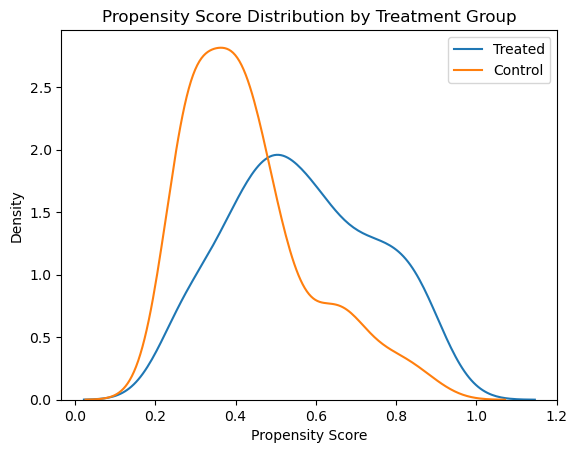

Estimated Average Treatment Effect (ATE): 0.2796170659306685

Sensitivity Analysis - Adding Random Common Cause:
 Refute: Add a random common cause
Estimated effect:0.2796170659306685
New effect:0.2796170659306685
p value:1.0


Sensitivity Analysis - Placebo Treatment Refuter:
 Refute: Use a Placebo Treatment
Estimated effect:0.2796170659306685
New effect:-0.17511016687826636
p value:0.0


Sensitivity Analysis - Data Subset Refuter:
 Refute: Use a subset of data
Estimated effect:0.2796170659306685
New effect:0.28085191989618874
p value:0.94


=== Prompt sent to LLaMA ===

Dataset summary for causal inference:

Treatment variable: Glucose_binary
  Binarized around median glucose level = 119.00
  Distribution: {0: 197, 1: 195}

Outcome variable: Outcome
  Distribution: {0: 262, 1: 130}

Confounders:
  Age: mean=0.00, std=1.00, min=-0.97, max=4.92
  BMI: mean=0.00, std=1.00, min=-2.12, max=4.85
  Pregnancies: mean=-0.00, std=1.00, min=-1.03, max=4.27


Propensity score model:
  - Logistic

Loading checkpoint shards: 100%|██████████| 2/2 [00:03<00:00,  1.69s/it]
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



=== LLaMA Causal Effect Interpretation ===

Dataset summary for causal inference:

Treatment variable: Glucose_binary
  Binarized around median glucose level = 119.00
  Distribution: {0: 197, 1: 195}

Outcome variable: Outcome
  Distribution: {0: 262, 1: 130}

Confounders:
  Age: mean=0.00, std=1.00, min=-0.97, max=4.92
  BMI: mean=0.00, std=1.00, min=-2.12, max=4.85
  Pregnancies: mean=-0.00, std=1.00, min=-1.03, max=4.27


Propensity score model:
  - Logistic regression fitted on confounders ['Age', 'BMI', 'Pregnancies']
  - Propensity score distribution plotted (overlap visually inspected)

Causal effect estimation:
  - Method: Doubly robust weighting
  - Estimated Average Treatment Effect (ATE): 0.280

Sensitivity analyses:
  - Random common cause refuter: 0.2796170659306685
  - Placebo treatment refuter: -0.17511016687826636
  - Data subset refuter: 0.28085191989618874

Please provide a detailed interpretation of this causal effect estimate,
discuss assumptions, potential sources

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import LlamaForCausalLM, LlamaTokenizer
from dowhy import CausalModel

# Load and preprocess dataset
df = pd.read_csv("diabetes.csv")

# Replace zeros with NaN for certain columns and drop missing rows
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    df[col] = df[col].replace(0, np.nan)
df.dropna(inplace=True)

# Binarize treatment variable 'Glucose' around median (required for propensity score methods)
glucose_threshold = df['Glucose'].median()
df['Glucose_binary'] = (df['Glucose'] > glucose_threshold).astype(int)

# Define variables
treatment = "Glucose_binary"
outcome = "Outcome"
confounders = ['Age', 'BMI', 'Pregnancies']

# Normalize confounders only
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[confounders] = scaler.fit_transform(df[confounders])

# Fit propensity score model explicitly using logistic regression
ps_model = LogisticRegression()
ps_model.fit(df_scaled[confounders], df_scaled[treatment])
df_scaled['propensity_score'] = ps_model.predict_proba(df_scaled[confounders])[:, 1]

# Plot propensity score distributions for treated vs control to check overlap
sns.kdeplot(df_scaled.loc[df_scaled[treatment] == 1, 'propensity_score'], label='Treated')
sns.kdeplot(df_scaled.loc[df_scaled[treatment] == 0, 'propensity_score'], label='Control')
plt.xlabel('Propensity Score')
plt.ylabel('Density')
plt.title('Propensity Score Distribution by Treatment Group')
plt.legend()
plt.show()

# Define causal graph (DAG)
causal_graph = """
digraph {
    Age -> Outcome;
    BMI -> Outcome;
    Pregnancies -> Outcome;
    Glucose_binary -> Outcome;
    Age -> Glucose_binary;
    BMI -> Glucose_binary;
    Pregnancies -> Glucose_binary;
}
"""

# Initialize causal model in DoWhy
model = CausalModel(
    data=df_scaled,
    treatment=treatment,
    outcome=outcome,
    common_causes=confounders,
    graph=causal_graph
)

# Identify causal effect estimand
identified_estimand = model.identify_effect()

# Estimate causal effect using propensity score weighting
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_weighting",
    target_units="ate"
)


print(f"Estimated Average Treatment Effect (ATE): {estimate.value}")

# Perform sensitivity analyses to check robustness
refute_random = model.refute_estimate(identified_estimand, estimate, method_name="random_common_cause")
refute_placebo = model.refute_estimate(identified_estimand, estimate, method_name="placebo_treatment_refuter")
refute_subset = model.refute_estimate(identified_estimand, estimate, method_name="data_subset_refuter")

print("\nSensitivity Analysis - Adding Random Common Cause:\n", refute_random)
print("\nSensitivity Analysis - Placebo Treatment Refuter:\n", refute_placebo)
print("\nSensitivity Analysis - Data Subset Refuter:\n", refute_subset)

# Summarize features for prompt to LLaMA
def summarize_feature(series):
    return f"mean={series.mean():.2f}, std={series.std():.2f}, min={series.min():.2f}, max={series.max():.2f}"

summary_text = f"""
Dataset summary for causal inference:

Treatment variable: {treatment}
  Binarized around median glucose level = {glucose_threshold:.2f}
  Distribution: {df_scaled[treatment].value_counts().to_dict()}

Outcome variable: {outcome}
  Distribution: {df_scaled[outcome].value_counts().to_dict()}

Confounders:
"""
for c in confounders:
    summary_text += f"  {c}: {summarize_feature(df_scaled[c])}\n"

summary_text += f"""

Propensity score model:
  - Logistic regression fitted on confounders {confounders}
  - Propensity score distribution plotted (overlap visually inspected)

Causal effect estimation:
  - Method: Doubly robust weighting
  - Estimated Average Treatment Effect (ATE): {estimate.value:.3f}

Sensitivity analyses:
  - Random common cause refuter: {refute_random.new_effect}
  - Placebo treatment refuter: {refute_placebo.new_effect}
  - Data subset refuter: {refute_subset.new_effect}

Please provide a detailed interpretation of this causal effect estimate,
discuss assumptions, potential sources of bias, robustness, and how
propensity score model diagnostics and sensitivity analyses inform confidence
in this estimate.
"""

print("\n=== Prompt sent to LLaMA ===")
print(summary_text)

# Load LLaMA model and tokenizer (adjust model path as needed)
model_name = "meta-llama/Llama-2-7b-hf"  # Replace with your model checkpoint if local
tokenizer = LlamaTokenizer.from_pretrained(model_name)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
llama_model = LlamaForCausalLM.from_pretrained(model_name).to(device)

def llama_causal_inference(prompt, max_new_tokens=250):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    outputs = llama_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Generate interpretation from LLaMA
causal_interpretation = llama_causal_inference(summary_text)

print("\n=== LLaMA Causal Effect Interpretation ===")
print(causal_interpretation)


# better code and more explanation compared to above

Causal Estimate (ATE):  0.2796170659306685


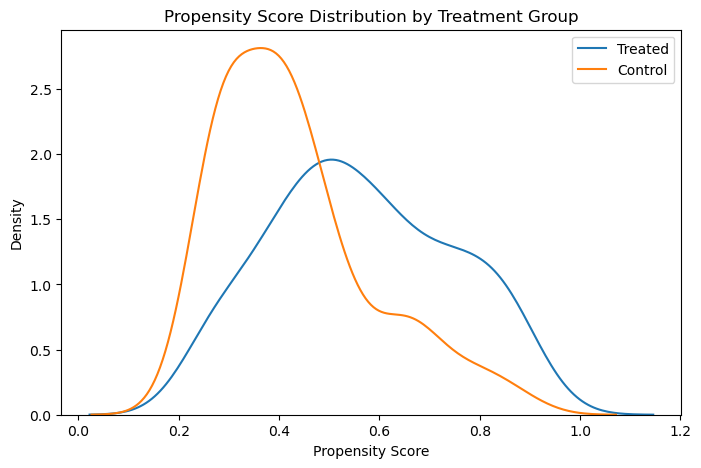

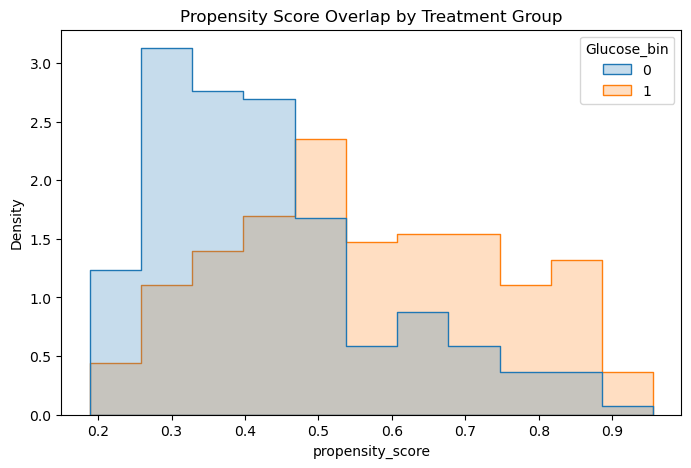


Running refutation tests...

Placebo Treatment Refuter Result:  Refute: Use a Placebo Treatment
Estimated effect:0.2796170659306685
New effect:-0.18166119857870602
p value:0.0

Random Common Cause Refuter Result:  Refute: Add a random common cause
Estimated effect:0.2796170659306685
New effect:0.2796170659306685
p value:1.0

Data Subset Refuter Result:  Refute: Use a subset of data
Estimated effect:0.2796170659306685
New effect:0.2791508763273989
p value:0.92

=== Dataset and causal inference summary sent to LLaMA ===

Dataset summary for causal inference:

Treatment variable: Glucose_bin (binary indicator if glucose > median)
  mean=0.50, std=0.50, min=0.00, max=1.00

Outcome variable: Outcome (binary diabetes diagnosis)
  Outcome distribution: {0: 262, 1: 130}

Confounders:
  Age: mean=0.00, std=1.00, min=-0.97, max=4.92
  BMI: mean=0.00, std=1.00, min=-2.12, max=4.85
  Pregnancies: mean=-0.00, std=1.00, min=-1.03, max=4.27


Estimated Average Treatment Effect (ATE) of Glucose_bin o

Loading checkpoint shards: 100%|██████████| 2/2 [00:03<00:00,  1.70s/it]



=== LLaMA Causal Effect Interpretation ===


Dataset summary for causal inference:

Treatment variable: Glucose_bin (binary indicator if glucose > median)
  mean=0.50, std=0.50, min=0.00, max=1.00

Outcome variable: Outcome (binary diabetes diagnosis)
  Outcome distribution: {0: 262, 1: 130}

Confounders:
  Age: mean=0.00, std=1.00, min=-0.97, max=4.92
  BMI: mean=0.00, std=1.00, min=-2.12, max=4.85
  Pregnancies: mean=-0.00, std=1.00, min=-1.03, max=4.27


Estimated Average Treatment Effect (ATE) of Glucose_bin on Outcome: 0.2796

Diagnostics:
- Propensity score distribution plotted.
- Common support assumption checked.
- Refutation tests performed:
  * Placebo treatment refuter: -0.18166119857870602
  * Random common cause refuter: 0.2796170659306685
  * Data subset refuter: 0.2791508763273989

Please provide a detailed interpretation of this causal effect estimate,
discuss assumptions, potential sources of bias, robustness, and how
propensity score model diagnostics and sensitivity

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

from dowhy import CausalModel

# Huggingface imports for LLaMA
from transformers import LlamaForCausalLM, LlamaTokenizer
import torch

# Load and preprocess dataset
df = pd.read_csv("diabetes.csv")

# Replace zeros with NaN for certain columns and drop rows with missing values
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    df[col] = df[col].replace(0, np.nan)
df.dropna(inplace=True)

# Binarize treatment based on median glucose (to get binary treatment)
treatment = "Glucose_bin"
df[treatment] = (df["Glucose"] > df["Glucose"].median()).astype(int)

outcome = "Outcome"
confounders = ['Age', 'BMI', 'Pregnancies']

# Normalize confounders (optional)
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[confounders] = scaler.fit_transform(df[confounders])

# Build DoWhy causal model
model = CausalModel(
    data=df_scaled,
    treatment=treatment,
    outcome=outcome,
    common_causes=confounders
)

# Identify causal effect
identified_estimand = model.identify_effect()

# Estimate causal effect using propensity score weighting
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_weighting",
    target_units="ate"
)

print("Causal Estimate (ATE): ", estimate.value)

# Manually compute propensity scores using logistic regression
ps_model = LogisticRegression(max_iter=1000)
ps_model.fit(df_scaled[confounders], df_scaled[treatment])
pscore = ps_model.predict_proba(df_scaled[confounders])[:, 1]  # P(Treatment=1)

df_scaled['propensity_score'] = pscore

# Plot propensity score distribution by treatment group
plt.figure(figsize=(8, 5))
sns.kdeplot(df_scaled.loc[df_scaled[treatment] == 1, 'propensity_score'], label='Treated')
sns.kdeplot(df_scaled.loc[df_scaled[treatment] == 0, 'propensity_score'], label='Control')
plt.title("Propensity Score Distribution by Treatment Group")
plt.xlabel("Propensity Score")
plt.ylabel("Density")
plt.legend()
plt.show()

# Plot propensity score overlap (common support)
plt.figure(figsize=(8, 5))
sns.histplot(data=df_scaled, x='propensity_score', hue=treatment, element="step", stat="density", common_norm=False)
plt.title("Propensity Score Overlap by Treatment Group")
plt.show()

# Sensitivity analyses / robustness checks (refutation tests)
print("\nRunning refutation tests...\n")
refute_placebo = model.refute_estimate(identified_estimand, estimate, method_name="placebo_treatment_refuter")
print("Placebo Treatment Refuter Result: ", refute_placebo)

refute_random_common_cause = model.refute_estimate(identified_estimand, estimate, method_name="random_common_cause")
print("Random Common Cause Refuter Result: ", refute_random_common_cause)

refute_subset = model.refute_estimate(identified_estimand, estimate, method_name="data_subset_refuter")
print("Data Subset Refuter Result: ", refute_subset)

# Prepare summary text for LLaMA prompt
def summarize_feature(series):
    return f"mean={series.mean():.2f}, std={series.std():.2f}, min={series.min():.2f}, max={series.max():.2f}"

summary_text = f"""
Dataset summary for causal inference:

Treatment variable: {treatment} (binary indicator if glucose > median)
  {summarize_feature(df_scaled[treatment])}

Outcome variable: {outcome} (binary diabetes diagnosis)
  Outcome distribution: {df_scaled[outcome].value_counts().to_dict()}

Confounders:
"""
for c in confounders:
    summary_text += f"  {c}: {summarize_feature(df_scaled[c])}\n"

summary_text += f"""

Estimated Average Treatment Effect (ATE) of {treatment} on {outcome}: {estimate.value:.4f}

Diagnostics:
- Propensity score distribution plotted.
- Common support assumption checked.
- Refutation tests performed:
  * Placebo treatment refuter: {refute_placebo.new_effect}
  * Random common cause refuter: {refute_random_common_cause.new_effect}
  * Data subset refuter: {refute_subset.new_effect}

Please provide a detailed interpretation of this causal effect estimate,
discuss assumptions, potential sources of bias, robustness, and how
propensity score model diagnostics and sensitivity analyses inform confidence
in this estimate.
"""

print("=== Dataset and causal inference summary sent to LLaMA ===")
print(summary_text)

# Load LLaMA model and tokenizer (adjust path/model name as needed)
model_name = "meta-llama/Llama-2-7b-hf"
tokenizer = LlamaTokenizer.from_pretrained(model_name)
llama_model = LlamaForCausalLM.from_pretrained(model_name).to('cuda' if torch.cuda.is_available() else 'cpu')

def llama_causal_inference(prompt, max_new_tokens=350):
    inputs = tokenizer(prompt, return_tensors="pt").to(llama_model.device)
    outputs = llama_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        eos_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Generate detailed interpretation from LLaMA
llama_prompt = summary_text
causal_effect_interpretation = llama_causal_inference(llama_prompt)

print("\n=== LLaMA Causal Effect Interpretation ===\n")
print(causal_effect_interpretation)
